In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhammetzahitaydn/hardhat-vest-dataset-v3")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hardhat-vest-dataset-v3' dataset.
Path to dataset files: /kaggle/input/hardhat-vest-dataset-v3


In [2]:
import os
DATASET_PATH = path

# Show contents of image and label directories
print("Training images:", len(os.listdir(f"{DATASET_PATH}/images/train")))
print("Validation images:", len(os.listdir(f"{DATASET_PATH}/images/val")))
print("Test images:", len(os.listdir(f"{DATASET_PATH}/images/test")))

Training images: 17248
Validation images: 2438
Test images: 2455


In [3]:
# 1. YAML Configuration Content
DATASET_PATH = path

yaml_content = f"""path: {DATASET_PATH}
train: images/train
val: images/val
nc: 3
names: ['hardhat', 'vest', 'person']
"""

# 2. Dataset Paths and Verification

print("Training images:", len(os.listdir(f"{DATASET_PATH}/images/train")))
print("Validation images:", len(os.listdir(f"{DATASET_PATH}/images/val")))
print("Test images:", len(os.listdir(f"{DATASET_PATH}/images/test")))

# Write out the YAML config file for YOLO training
with open('hardhat.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ Updated YAML for dataset-v3 created!")



Training images: 17248
Validation images: 2438
Test images: 2455
✅ Updated YAML for dataset-v3 created!


## Dataset validation
Checks image/label pairing, malformed annotation lines, corrupt images, and class balance across splits .

In [4]:
def check_image_label_pairing(dataset_path, split):
    """Every image should have exactly one matching label file, and vice versa."""
    img_dir = f"{dataset_path}/images/{split}"
    lbl_dir = f"{dataset_path}/labels/{split}"

    img_stems = {os.path.splitext(f)[0] for f in os.listdir(img_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
    lbl_stems = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir)
                 if f.lower().endswith('.txt')}

    images_without_labels = img_stems - lbl_stems
    labels_without_images = lbl_stems - img_stems

    print(f"--- {split} ---")
    print(f"  images: {len(img_stems)}  labels: {len(lbl_stems)}")
    print(f"  images without a label file: {len(images_without_labels)}")
    print(f"  label files without an image: {len(labels_without_images)}")
    if images_without_labels:
        print("  e.g.", list(images_without_labels)[:5])
    if labels_without_images:
        print("  e.g.", list(labels_without_images)[:5])
    return images_without_labels, labels_without_images

for split in ['train', 'val', 'test']:
    check_image_label_pairing(DATASET_PATH, split)

--- train ---
  images: 17248  labels: 17248
  images without a label file: 0
  label files without an image: 0
--- val ---
  images: 2438  labels: 2438
  images without a label file: 0
  label files without an image: 0
--- test ---
  images: 2455  labels: 2455
  images without a label file: 0
  label files without an image: 0


In [5]:
def validate_label_files(dataset_path, split, num_classes=3):
    """Check every label line has 5 fields, class_id in range, and
    normalized coords in [0, 1]. Corrupt lines can silently break training
    or produce nonsense boxes."""
    lbl_dir = f"{dataset_path}/labels/{split}"
    bad_files = []

    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'):
            continue
        fpath = os.path.join(lbl_dir, fname)
        with open(fpath) as f:
            for line_num, line in enumerate(f, 1):
                parts = line.strip().split()
                if not parts:
                    continue
                if len(parts) != 5:
                    bad_files.append((fname, line_num, "wrong number of fields"))
                    continue
                try:
                    class_id = int(parts[0])
                    coords = list(map(float, parts[1:]))
                except ValueError:
                    bad_files.append((fname, line_num, "non-numeric value"))
                    continue
                if not (0 <= class_id < num_classes):
                    bad_files.append((fname, line_num, f"class_id {class_id} out of range"))
                if not all(0.0 <= c <= 1.0 for c in coords):
                    bad_files.append((fname, line_num, "coordinate out of [0,1]"))

    print(f"--- {split}: {len(bad_files)} problem line(s) ---")
    for fname, line_num, reason in bad_files[:10]:
        print(f"  {fname} (line {line_num}): {reason}")
    return bad_files

for split in ['train', 'val', 'test']:
    validate_label_files(DATASET_PATH, split, num_classes=3)

--- train: 0 problem line(s) ---
--- val: 0 problem line(s) ---
--- test: 0 problem line(s) ---


### Class Distribution

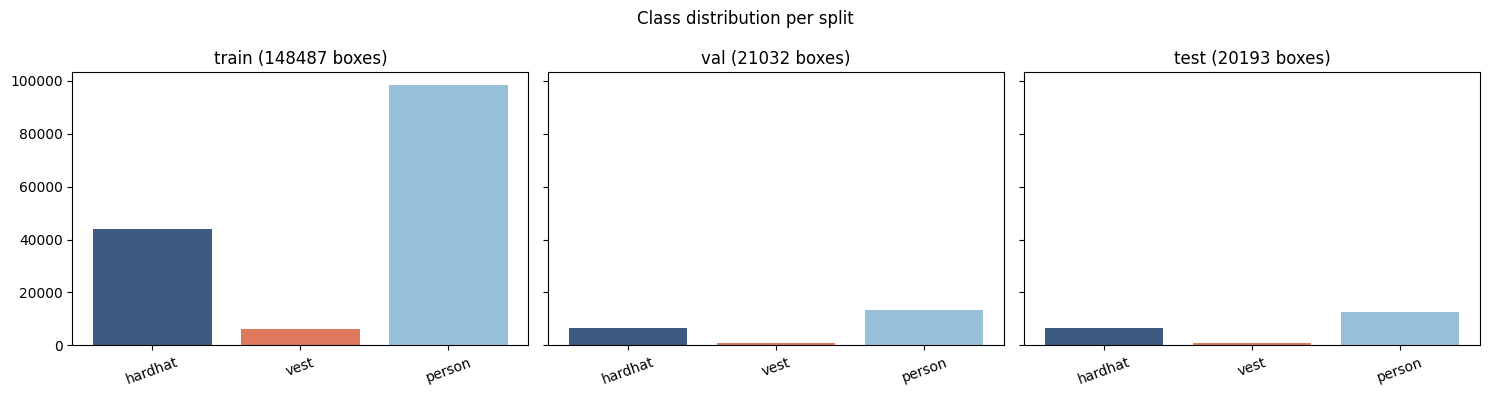

In [6]:
from collections import Counter
import matplotlib.pyplot as plt

CLASS_NAMES = ['hardhat', 'vest', 'person']

def class_distribution(dataset_path, split):
    lbl_dir = f"{dataset_path}/labels/{split}"
    counts = Counter()
    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(lbl_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, split in zip(axes, ['train', 'val', 'test']):
    counts = class_distribution(DATASET_PATH, split)
    values = [counts.get(i, 0) for i in range(len(CLASS_NAMES))]
    ax.bar(CLASS_NAMES, values, color=['#3d5a80', '#e07a5f', '#98c1d9'])
    ax.set_title(f"{split} ({sum(values)} boxes)")
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Class distribution per split")
plt.tight_layout()
plt.show()

## Visualize Random Samples

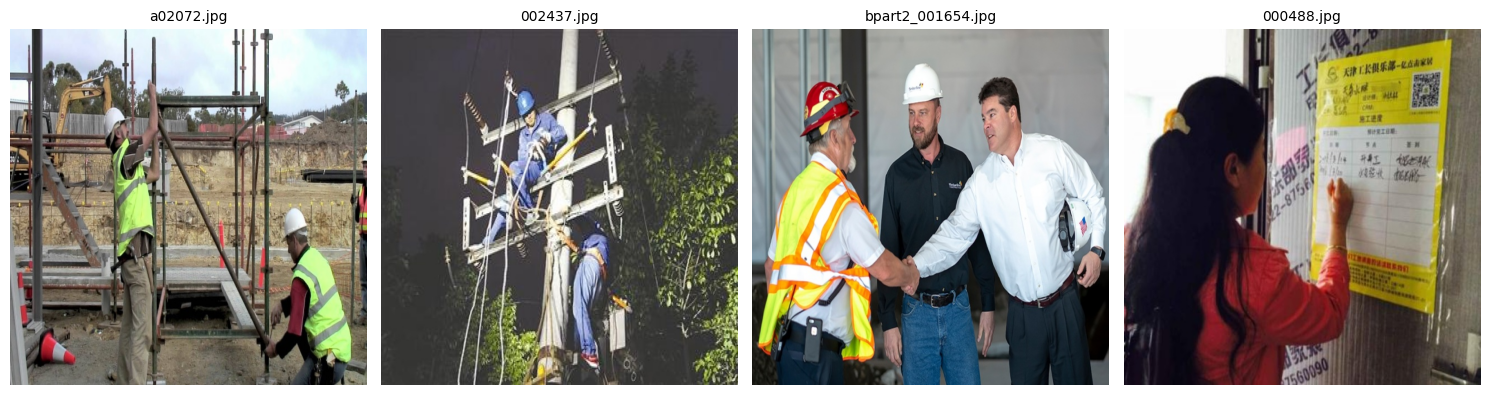

In [7]:
import random
import cv2

def visualize_raw_training_images(image_dir, num_images=4):

    # Get all image filenames in the training directory
    valid_extensions = ('.jpg', '.jpeg', '.png')
    all_images = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_extensions)]

    if not all_images:
        print(f"No images found in {image_dir}")
        return

    # Pick a random sample of images
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    # Set up a grid to display them
    fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 5))
    if len(selected_images) == 1:
        axes = [axes] # Handle case for a single image

    for ax, img_name in zip(axes, selected_images):
        img_path = os.path.join(image_dir, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            # Convert BGR to RGB for correct colors in Matplotlib
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.set_title(img_name, fontsize=10)
        else:
            ax.set_title(f"Failed to load: {img_name}", fontsize=10)

        ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- Run the function ---
TRAIN_IMAGE_DIR = f'{DATASET_PATH}/images/train'
visualize_raw_training_images(TRAIN_IMAGE_DIR, num_images=4)

### Visual Bounding Box Verification

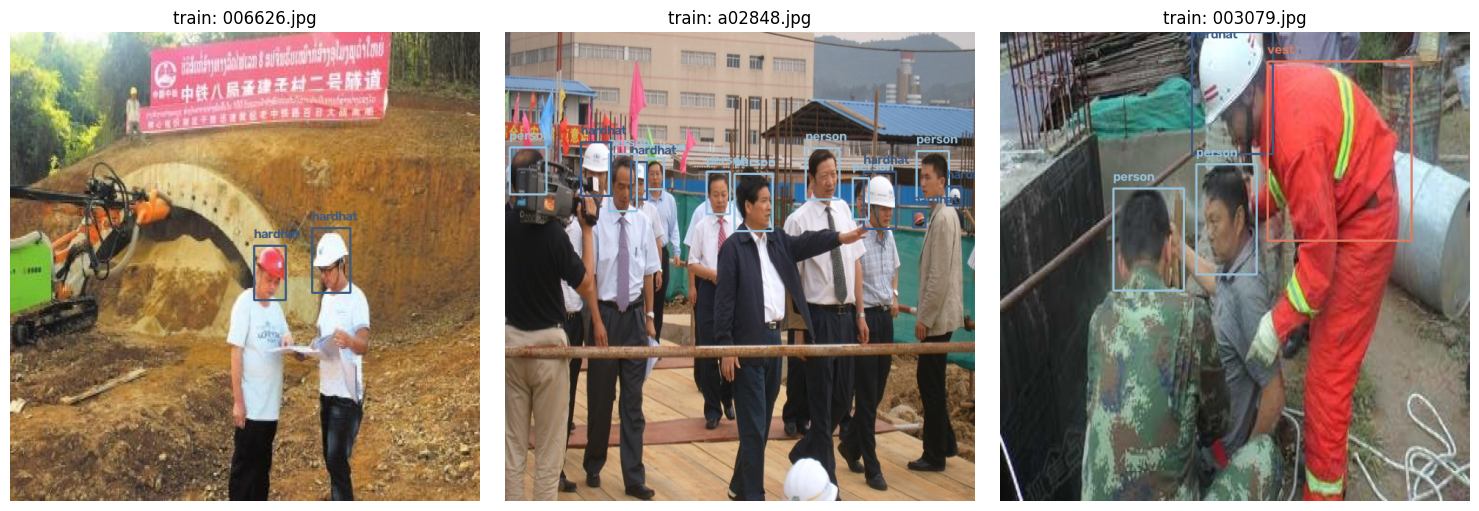

In [8]:

from PIL import Image

def visualize_random_samples(dataset_path, split, num_samples=3):
    img_dir = f"{dataset_path}/images/{split}"
    lbl_dir = f"{dataset_path}/labels/{split}"

    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_imgs = random.sample(images, min(num_samples, len(images)))

    plt.figure(figsize=(15, 5))
    for idx, img_name in enumerate(sample_imgs):
        img_path = os.path.join(img_dir, img_name)
        stem = os.path.splitext(img_name)[0]
        lbl_path = os.path.join(lbl_dir, f"{stem}.txt")

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        # Read labels
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(parts[0])
                        x_center, y_center, box_w, box_h = map(float, parts[1:])

                        # Convert YOLO normalized coords to pixel coords
                        xmin = int((x_center - box_w / 2) * w)
                        ymin = int((y_center - box_h / 2) * h)
                        xmax = int((x_center + box_w / 2) * w)
                        ymax = int((y_center + box_h / 2) * h)

                        # Draw box
                        color = [(61, 90, 128), (224, 122, 95), (152, 193, 217)][cls_id]
                        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)
                        cv2.putText(img, CLASS_NAMES[cls_id], (xmin, max(ymin - 10, 10)),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        plt.subplot(1, num_samples, idx + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{split}: {img_name}")
    plt.tight_layout()
    plt.show()

visualize_random_samples(DATASET_PATH, 'train', num_samples=3)

### Degenerate Bounding Box Check
Sometimes annotation tools export boxes with width or height equal to 0.0, which can cause division-by-zero errors or NaN losses during training.

In [9]:
def check_degenerate_boxes(dataset_path, split):
    lbl_dir = f"{dataset_path}/labels/{split}"
    degenerate_count = 0

    for fname in os.listdir(lbl_dir):
        if not fname.endswith('.txt'): continue
        with open(os.path.join(lbl_dir, fname)) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, _, _, w, h = map(float, parts)
                    if w == 0.0 or h == 0.0:
                        degenerate_count += 1

    print(f"--- {split}: {degenerate_count} degenerate box(es) found (w or h == 0) ---")

for split in ['train', 'val', 'test']:
    check_degenerate_boxes(DATASET_PATH, split)

--- train: 0 degenerate box(es) found (w or h == 0) ---
--- val: 0 degenerate box(es) found (w or h == 0) ---
--- test: 0 degenerate box(es) found (w or h == 0) ---


### Check Safety for Jacjket & helmet

In [10]:
# Safety Gear Compliance Evaluator Function
def check_safety_compliance(detected_classes):
    """
    Evaluates safety gear compliance based on detected classes
    ('hardhat' = 0, 'vest' = 1, 'person' = 2).
    """
    has_helmet = 'hardhat' in detected_classes or 0 in detected_classes
    has_vest = 'vest' in detected_classes or 1 in detected_classes

    if has_helmet and has_vest:
        return "Wearing both (Helmet & Vest)", (0, 255, 0)      # green
    elif has_helmet and not has_vest:
        return "Wearing Helmet only (No Vest)", (0, 165, 255)   # orange
    elif not has_helmet and has_vest:
        return "Wearing Vest only (No Helmet)", (0, 165, 255)   # orange
    else:
        return "Wearing neither", (0, 0, 255)

In [11]:
import cv2
import matplotlib.pyplot as plt

def visualize_yolo_with_compliance(image_path, label_path, class_names):

    img = cv2.imread(image_path)
    if img is None:
        print(f"Error loading image from: {image_path}")
        return

    h, w, _ = img.shape
    detected_classes = []

    # Read label file if it exists
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue

            class_id = int(parts[0])
            detected_classes.append(class_id)

            x_center, y_center, box_width, box_height = map(float, parts[1:])

            # Convert YOLO normalized coordinates to pixel coordinates
            x1 = int((x_center - box_width / 2) * w)
            y1 = int((y_center - box_height / 2) * h)
            x2 = int((x_center + box_width / 2) * w)
            y2 = int((y_center + box_height / 2) * h)

            color = (0, 255, 0) if class_id != 2 else (255, 0, 0) # Green for gear, Blue for person
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

            label_text = class_names[class_id] if class_id < len(class_names) else str(class_id)
            cv2.putText(img, label_text, (x1, max(y1 - 10, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    else:
        print(f"Label file not found: {label_path}")

    # Evaluate compliance based on all objects found in the frame
    status_text, status_color = check_safety_compliance(detected_classes)

    # Overlay compliance status banner at the top of the image
    cv2.putText(img, f"Status: {status_text}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, status_color, 3, cv2.LINE_AA)

    # Convert BGR to RGB for Matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(9, 9))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("YOLO Safety Compliance Visualization", fontsize=14)
    plt.show()


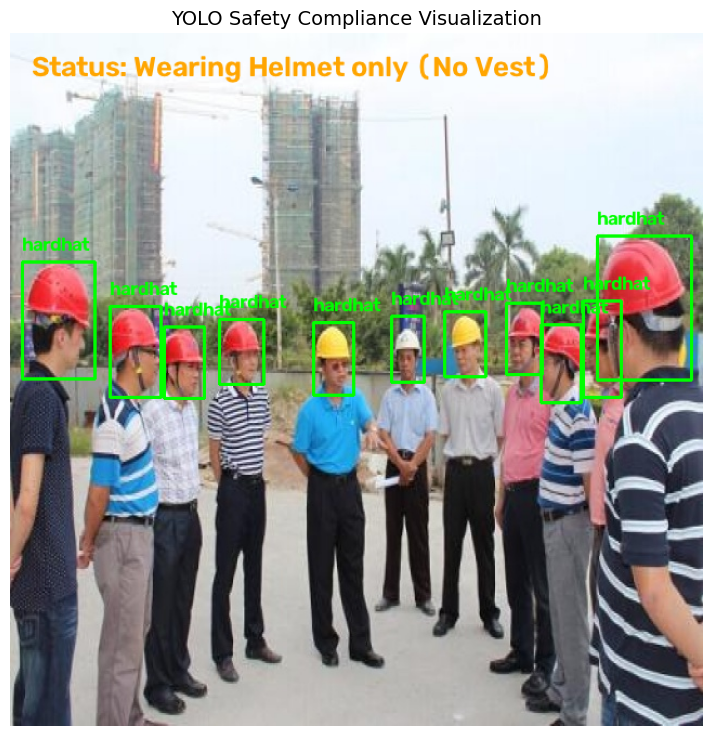

In [12]:
# --- Example Usage ---
CLASSES = ['hardhat', 'vest', 'person']
img_file = f'{DATASET_PATH}/images/train/000090.jpg'
lbl_file = f'{DATASET_PATH}/labels/train/000090.txt'
visualize_yolo_with_compliance(img_file, lbl_file, CLASSES)

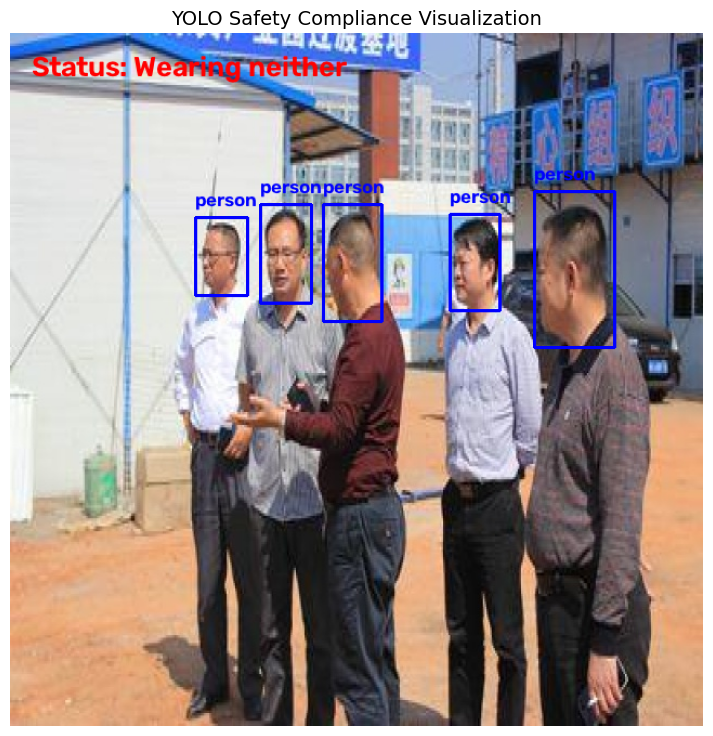

In [13]:
# --- Another Example Usage ---
CLASSES = ['hardhat', 'vest', 'person']
img_file = f'{DATASET_PATH}/images/train/000019.jpg'
lbl_file = f'{DATASET_PATH}/labels/train/000019.txt'
visualize_yolo_with_compliance(img_file, lbl_file, CLASSES)